### Метрики эффективности моделей машинного обучения

#### Цель работы

Научиться измерять эффективность моделей машинного обучения с помощью метрик, вибирать метрики исходя из задачи, разбивать датасет на обучающую и тестовую подвыборки.


#### Методические указания

После чтения файла вы должны увидеть примерно такую таблицу при выводе первых строк датасета:

In [1]:
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

# Прямая ссылка на raw-файл heart.csv из вашего репозитория
url = "https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML4.1%20metrics/data/heart.csv"

# Чтение данных напрямую из URL
data = pd.read_csv(url)

# Проверка, что данные загрузились
print(data.head())

   age  sex  cp  trtbps  chol  fbs  restecg  thalachh  exng  oldpeak  slp  \
0   63    1   3     145   233    1        0       150     0      2.3    0   
1   37    1   2     130   250    0        1       187     0      3.5    0   
2   41    0   1     130   204    0        0       172     0      1.4    2   
3   56    1   1     120   236    0        1       178     0      0.8    2   
4   57    0   0     120   354    0        1       163     1      0.6    2   

   caa  thall  output  
0    0      1       1  
1    0      2       1  
2    0      2       1  
3    0      2       1  
4    0      2       1  


Как всегда выделим целевую переменную, сразу же импортируем и обучим модель логистической регрессии:

In [2]:
y = data["output"]
x = data.drop("output", axis=1)

from sklearn.linear_model import LogisticRegression

logistic = LogisticRegression().fit(x, y)
logistic.score(x, y)

0.8547854785478548

Данная модель показывает более 85% точности. Но эта оценка качества модели является завышенной (оптимистичной), так как она оценена именно по тем данным, на которых модель училась. Чтобы оценить именно обобщающую способность модели, то есть ее способность правильно предсказывать значение целевой переменной для тех объектов, которые она не учитывала при подстройке параметров, необходимо оценить модель на другой выборке. Для этого нужно разделить исходный датасет на две части. Обучающая выборка (первая часть) будет использоваться для нахождения оптимальных значений внутренних параметров модели, а тестовая выборка (вторая часть) - для оценки качества полученной модели.

##### Разделение выборки

Делить датасет можно разными способами. Важно, чтобы каждый конкретный объект попал только в одну выборку - либо тестовую, либо обучающую. То есть эти части должны быть непересекающиеся. Самый простой способ - просто взять какое-то количество объектов в начале датафрейма в обучающую выборку, а остальные - в тестовую. То есть мы просто берем несколько первых строчек (например, 200) для обучающей выборки:

In [3]:
x_train, y_train = x[:200], y[:200]

Важно убедиться, что все в порядке с формами получившихся массивов:

In [4]:
x_train.shape, y_train.shape

((200, 13), (200,))

Итак, первые 200 строк попали в обучающую выборку. Тогда тестовую выборку составять оставшиеся строки датасета:

In [5]:
x_test, y_test = x[200:], y[200:]
x_test.shape, y_test.shape

((103, 13), (103,))

Получилось, что в тестовой выборке осталось 103 объекта. Теперь можно заново обучить модель классификации и оценить ее качество. Обратите внимание, что мы вызываем метод fit() именно на обучающей части датасета. А вот эффективность измеряем сначала на обучающей части, а затем на тестовой, чтобы сравнить:

In [6]:
logistic_test = LogisticRegression().fit(x_train, y_train)
logistic_test.score(x_train, y_train), logistic_test.score(x_test, y_test)

(0.9, 0.5436893203883495)

Получилось, что на обучающей выборки точность модели даже немного повысилась, до 90%. Это произошло за счет того, что в обучающей выборке меньше данных, чем в целом датасете. А чем меньше точек, тем проще модели под них подстроиться. А вот эффективность модели на тестовых данных стала сильно ниже - всего 54%. Это значит, что наша модель чуть лучше, чем простое угадывание. Хотя, как увидим дальше, на самом деле не все так плохо.

Вместо того, чтобы вручную задавать количество объектов, которые отводятся на обучающую выборку, можно выразить это количество через процент от всего объема датасета. Это даст нам универсальность:



In [7]:
N = int(x.shape[0] * 0.8)

x_train, y_train, x_test, y_test = x[:N], y[:N], x[N:], y[N:]
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((242, 13), (242,), (61, 13), (61,))

В данном примере мы взяли 80% объектов для обучающей выборки и 20% - оставили на тестовую. Это довольно стандартная схема разбиения и мы в общем случае будем придерживаться именно ее. Вот какие формы получились у массивов:

Давайте еще раз обучим и оценим модель, уже на новом разделении:

In [8]:
logistic_test = LogisticRegression().fit(x_train, y_train)
logistic_test.score(x_train, y_train), logistic_test.score(x_test, y_test)

(0.8884297520661157, 0.6229508196721312)

Мы видим, что точность на обучающей выборке (мы ее будем называть обучающей точностью) чуть опустилась - опять же это эффект количества точек - сейчас их чуть больше. Но и тестовая эффективность (точность модели, измеренная на тестовой выборке) тоже подросла - до 62%. Это потому, что чем больше примеров мы использовали для обучения, тем более качественной и обобщающей получается наша модель.

Но разнича между обучающей и тестовой точностью у нашей модели все еще довольно высока. С чем это может быть связано? На самом деле, мы поступаем немного неправильно. Нам нужно более внимательно присмотреться к данным. Мы уже видели первые несколько строк датасета. Давайте еще выведем последние несколько строк:

In [9]:
data.tail()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


Можно заметить, что вы первой половине данных целевая переменная всегда положительная, а во второй - отрицательная. Другими словами, датасет отсортирован по значению целевой переменной. Поэтому наше разбиение имеет один неприятный эффект - в обучающей выборке скапливается большое количество положительных примеров, а в тестовой - только отрицательные. Другими словами, обучающая и тестовая выборки очень непохожи друг надруга. А для того, чтобы наше оценивание сработало, нужно, чтобы они были как можно более однородными.

Поэтому просто выбрать первые строки датасета обычно не очень рациональное решение. Даже если датасет не отсортирован по значению целевой переменной, он вполне может быть упорядочен по какому-то другому признаку, или хотя бы по времени добавления объектов в набор или базу данных. А такое упорядочение вносит систематическую ошибку выборки, которая смещает оценку качества модели.

Из-за этого делить данные на обучающую и тестовую выборки практически всегда нужно случайным образом. То есть выбрать случайное подмножество точек и поместить их в обучающий набор, а оставшиеся - в тестовый. Основная техническая трудность здесь состоит в том, что датасет у нас разделен на две переменные - матрицу признаков и вектор значений целевой переменной. Просто воспользоваться методом случайного выбора из массива мы не можем, так как когда мы повторим его два раза - для переменных x и y у нас будут выбраны не соответствующие друг другу объекты.

Для решения этой проблемы воспользуемся индексными масками. Заведем массив булевских значений, в которых количество истинных значений будет соответствовать желаемому объему обучающей выборки, а ложных - объему тестовой:

In [10]:
import numpy as np

mask = np.array([True] * N + [False] * (y.shape[0] - N))

В сумме должно получиться в точности количество объектов в полном датасете.Теперь перемешаем этот массив, используя стандартную функцию numpy:

In [11]:
from numpy.random import shuffle

shuffle(mask)
mask

array([False,  True,  True,  True,  True,  True,  True,  True,  True,
       False,  True, False,  True,  True,  True,  True, False,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False,  True,  True,  True, False,  True,
        True,  True,  True,  True,  True, False,  True,  True,  True,
       False,  True,  True,  True,  True,  True,  True, False,  True,
        True,  True,  True, False,  True,  True,  True,  True,  True,
        True, False,  True,  True, False,  True, False,  True,  True,
       False,  True,  True,  True, False, False,  True,  True,  True,
       False,  True,  True,  True,  True,  True,  True,  True, False,
        True,  True,  True,  True, False,  True, False,  True,  True,
        True, False,  True,  True,  True,  True,  True,  True, False,
        True, False, False,  True, False,  True,  True,  True, False,
        True, False,  True, False,  True,  True, False,  True,  True,
        True,  True,

Этот булев массив можно использовать как маску при индексировании исходного датасета. Если выбрать данные по этой маске, то в итог попадут только те элементы, которые стоят на тех местах, на которых в маске - истина:

In [12]:
x_train = x[mask]
x_train.shape

(242, 13)

Смысл этого приема в том, что мы можем применить одну и ту же маску к обоим частям массива. А если инвертировать эту маску, то выберем оставшиеся значения:

In [13]:
x_train, y_train, x_test, y_test = x[mask], y[mask], x[~mask], y[~mask]
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((242, 13), (242,), (61, 13), (61,))

После такого разделения опять обучим и оценим модель:

In [14]:
logistic_test = LogisticRegression().fit(x_train, y_train)
logistic_test.score(x_train, y_train), logistic_test.score(x_test, y_test)

(0.8471074380165289, 0.8852459016393442)

Мы видим, что теперь разница между тестовой и обучающей выборкой стала гораздо меньше - 88% и 77% соответственно. Это как раз обосновано более правильным разделением, которое дает однородные по своему составу части датасета.

Конечно, такая стандартная процедура как случайное разделение датасета на две части уже реализована в виде готовой функции - в реальной работе не придется каждый раз дублировать приведенный код. Такая функция лежит в пакете sklearn, который отвечает за методологию выбора модели - обэтом мы поговорим в следующих работах:

In [15]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((242, 13), (242,), (61, 13), (61,))

Обратите внимание, что библиотечная функция возвращает элементы в строго определенном порядке. Его придется либо запомнить, либо пользоваться готовыми сниппетами кода.

##### Построение метрик качества классификации

До сих пор мы оценивали модель только по одной метрике эффективности. Но для более полного анализе этого недостаточно. В пакете _metrics_ собрано множество функций, которые позволяют исследовать поведение уже обученных моделей, в том числе - метрики эффективности. Импортируем несколько нужных нам инструментов:



In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

Для использования большинства метрик необходимо передавать в эти функции два вектора - вектор истинных значений целевой переменной и вектор предсказанных значений. Истинные (эмпирические) значения - это часть исходного датасета. А предсказанные (теоретические) значения можно вычислить. Рассчитаем предсказанные значения отдельно для обучающей и для тестовой выборки:

In [17]:
y_test_pred = logistic_test.predict(x_test)
y_train_pred = logistic_test.predict(x_train)

Первым делом построим матрицу классификации:

Text(0.5, 1.0, 'Матрица ошибок')

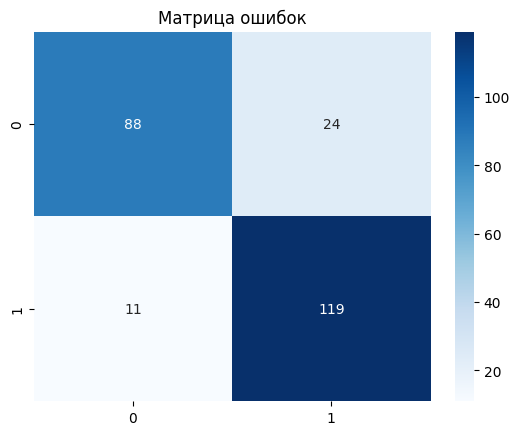

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_train, y_train_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок')


Она показывает, как часто и в каких классах модель ошибается. В идеальной модели ненулевые значения должны быть только на главной диагонали:

Обратите внимание, что для правильного анализа модели нужно строить все эти диагностические инструменты именно по тестовой выборке:

Text(0.5, 1.0, 'Матрица ошибок')

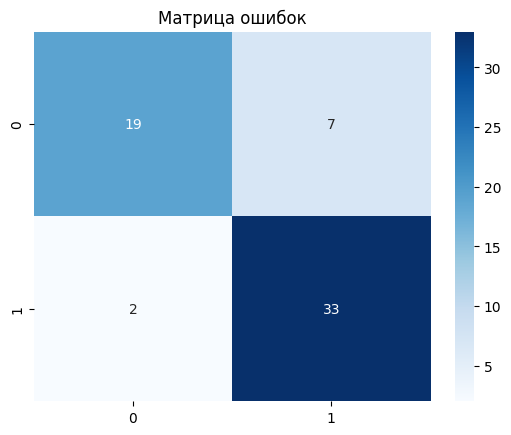

In [19]:
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок')

Именно эти данные покажут истинное поведение модели.

Еще один полезный инструмент - отчет о классификации:

In [20]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.90      0.73      0.81        26
           1       0.82      0.94      0.88        35

    accuracy                           0.85        61
   macro avg       0.86      0.84      0.84        61
weighted avg       0.86      0.85      0.85        61



Он показывает всю основную информацию по итогам классификации. Познакомьтесь со структурой данного отчета и проинтерпретируйте полученные результаты.

Что касается остальных метрик качества классификации, можно строить их отдельно:

In [21]:
precision_score(y_test, y_test_pred)

0.825

Но более удобно свести их все в таблицу при помощи датафрейма:

In [22]:
metrics = pd.DataFrame({
    "Train": [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred),
        recall_score(y_train, y_train_pred),
        f1_score(y_train, y_train_pred),
    ],
    "Test": [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred),
    ],
}, index = ["Accuracy", "Precision", "Recall", "F1"])

metrics

,Train,Test
Accuracy,0.855372,0.852459
Precision,0.832168,0.825000
Recall,0.915385,0.942857
F1,0.871795,0.880000


Здесь мы видим сравнение четырех разных основных метрик качества модели классификации по обучающей и по тестовой выборкам. Видно, что тестовые метрики все чуть ниже, чем обучающие. Это доволно типичное поведение моделей машинного обучения. Мы уже рассматривали причины этого. Но помните, что это не гарантируется и в конкретном случае, тестовые метрики могут быть как очень близки, так и даже выше. Все решает случай при рандомном разеделении выборки.

При оценке эффективности модели машинного обучения ориентирвоаться нужно только на тестовые метрики. Но сравнение уровня тестовой и обучающей метрики - это один их основных инструментов диагностики модели машинного обучения.

#### Задания для самостоятельного выполнения

1. Повторите анализ для других видов моделей. Используйте 5-10 разных классов моделей. Подсчитывайте только метрики на тестовой выборке.

In [23]:
# 3. Разделение на обучающую и тестовую выборки (80/20, стратификация, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [24]:
from sklearn.preprocessing import StandardScaler

# 4. Масштабирование для MLP
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier


# 5. Список моделей (для MLP используем масштабированные данные)
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42),
    'k-NN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'MLP (2 слоя)': MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=1000, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, random_state=42)
}

In [26]:
# 6. Обучение моделей и сбор метрик на тесте
results = []
model_predictions = {}       # предсказания на тесте
model_predictions_train = {} # предсказания на обучении

for name, model in models.items():
    if name == 'MLP (2 слоя)':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_pred_train = model.predict(X_train_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_train = model.predict(X_train)

    model_predictions[name] = y_pred
    model_predictions_train[name] = y_pred_train

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    results.append([name, acc, prec, rec, f1])

In [27]:
# 7. Сводная таблица метрик на тестовой выборке (сравнение моделей)
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])
results_df = results_df.sort_values(by="F1-score", ascending=False)
print("\n=== Сводка метрик на тестовой выборке ===")
results_df


=== Сводка метрик на тестовой выборке ===


,Model,Accuracy,Precision,Recall,F1-score
2,Random Forest,0.836066,0.780488,0.969697,0.864865
3,Gradient Boosting,0.819672,0.789474,0.909091,0.845070
9,Extra Trees,0.819672,0.789474,0.909091,0.845070
6,Naive Bayes,0.819672,0.789474,0.909091,0.845070
8,AdaBoost,0.819672,0.789474,0.909091,0.845070
0,Logistic Regression,0.803279,0.769231,0.909091,0.833333
7,MLP (2 слоя),0.786885,0.794118,0.818182,0.805970
1,Decision Tree,0.704918,0.702703,0.787879,0.742857
4,SVM (RBF),0.655738,0.650000,0.787879,0.712329
5,k-NN (k=5),0.590164,0.625000,0.606061,0.615385


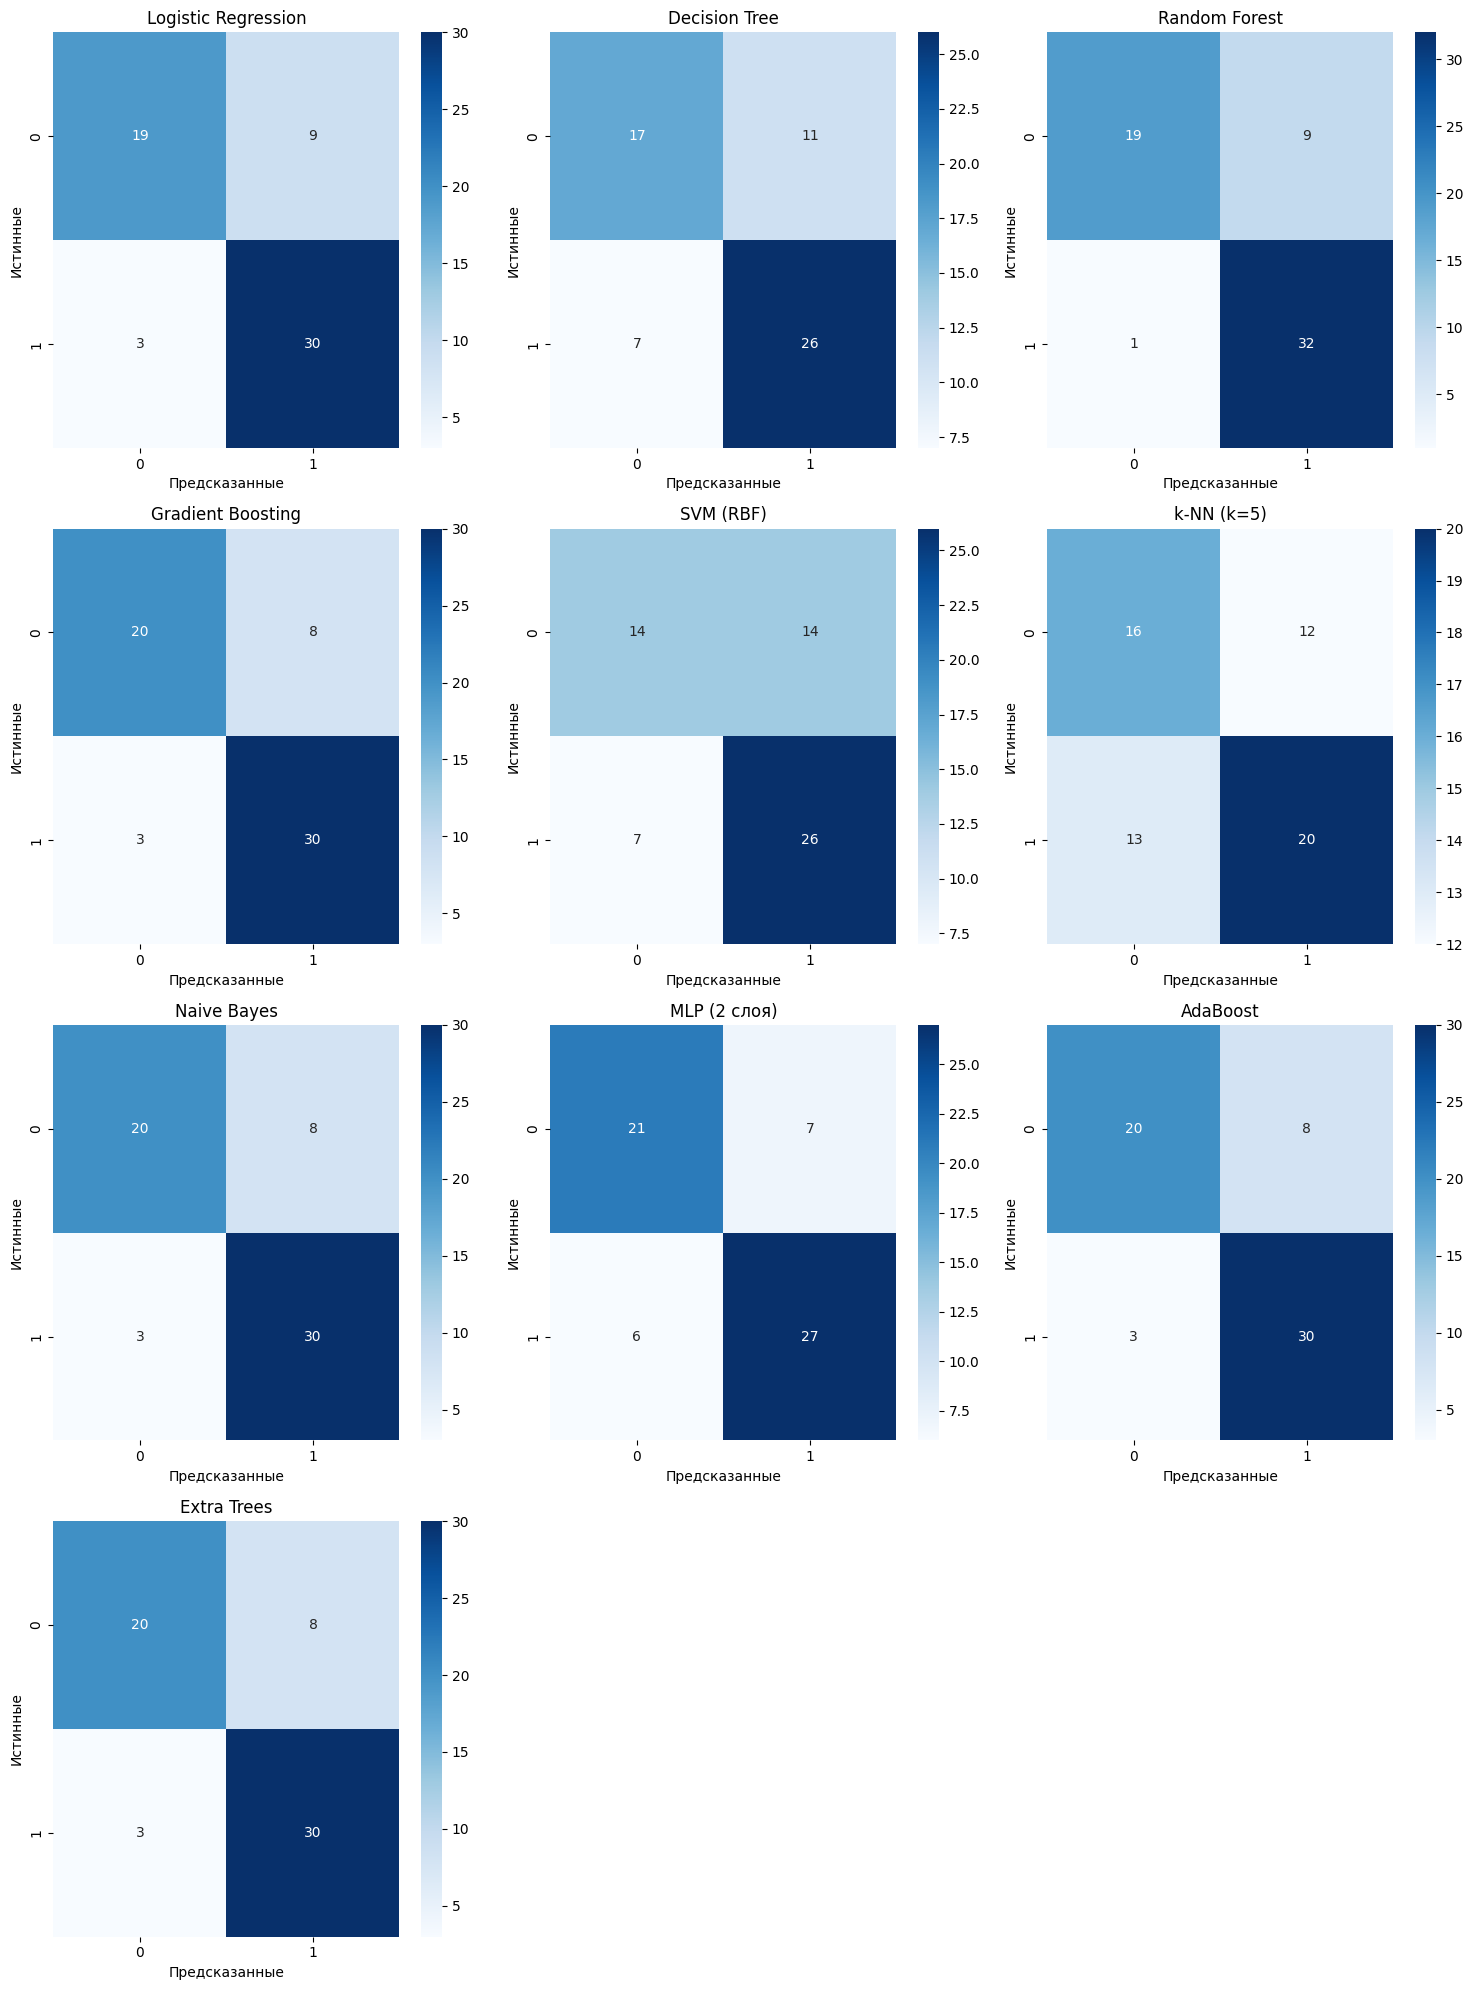

In [28]:
# 8. Визуализация матриц ошибок в сетке 3 столбца
n_models = len(model_predictions)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(model_predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_xlabel('Предсказанные')
    axes[i].set_ylabel('Истинные')

# Удалить лишние пустые подграфики (если моделей меньше, чем ячеек)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [29]:
# Для лучшей модели (по F1-score)
best_model_name = results_df.iloc[0]["Model"]
best_y_pred = model_predictions[best_model_name]
best_y_pred_train = model_predictions_train[best_model_name]

metrics = pd.DataFrame({
    "Train": [
        accuracy_score(y_train, best_y_pred_train),
        precision_score(y_train, best_y_pred_train, zero_division=0),
        recall_score(y_train, best_y_pred_train, zero_division=0),
        f1_score(y_train, best_y_pred_train, zero_division=0),
    ],
    "Test": [
        accuracy_score(y_test, best_y_pred),
        precision_score(y_test, best_y_pred, zero_division=0),
        recall_score(y_test, best_y_pred, zero_division=0),
        f1_score(y_test, best_y_pred, zero_division=0),
    ],
}, index=["Accuracy", "Precision", "Recall", "F1"])
print("\n=== Сводка метрик Для лучшей модели (по F1-score) ===")
metrics


=== Сводка метрик Для лучшей модели (по F1-score) ===


,Train,Test
Accuracy,1.0,0.836066
Precision,1.0,0.780488
Recall,1.0,0.969697
F1,1.0,0.864865


## Вывод по заданию 1

- **Лучшая модель** на тестовой выборке – **Random Forest** (F1-score = 0.865, Accuracy = 0.836).  
- Несколько моделей показали близкие результаты: Gradient Boosting, Extra Trees, Naive Bayes, AdaBoost (F1 ≈ 0.845).  
- Логистическая регрессия и MLP (2 слоя) дали F1 ≈ 0.83–0.81.  
- Хуже всего выступили SVM (RBF), Decision Tree и k-NN (F1 ≈ 0.74, 0.71, 0.62).  

- У лучшей модели (Random Forest) **обучающие метрики** (Accuracy, Precision, Recall, F1) равны **1.0**, что указывает на **переобучение** (модель идеально запомнила обучающую выборку, но на тесте качество ниже).  
- Тем не менее, тестовые метрики остаются достаточно высокими, что делает модель пригодной для практического использования.  

**Рекомендация:** Для повышения обобщающей способности Random Forest можно уменьшить глубину деревьев или увеличить `min_samples_leaf`. В целом, для данного датасета (сердечные заболевания) ансамблевые методы (Random Forest, Gradient Boosting) работают лучше всего.

2. Повторите анализ для другого датасета по вашему выбору. Используйте несколько моделей для сравнения. Используйте датасет для множественной классификации.

In [30]:
from sklearn.datasets import load_iris

# 1. Загрузка данных (множественная классификация)
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print("Датасет Iris")
print(f"Размер X: {X.shape}, классов: {len(target_names)}")
print(f"Классы: {target_names}")
data.head()

Датасет Iris
Размер X: (150, 4), классов: 3
Классы: ['setosa' 'versicolor' 'virginica']


,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [31]:
# 2. Разделение на обучающую и тестовую выборки (80/20, стратификация)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [32]:
# 3. Масштабирование для моделей, чувствительных к масштабу (MLP, SVM, KNN, логистическая регрессия)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
# 5. Обучение и сбор метрик (средние по макро)
results = []
preds_test = {}
preds_train = {}

for name, model in models.items():
    if name in ['Logistic Regression', 'SVM (RBF)', 'k-NN (k=5)', 'MLP (2 слоя)']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_pred_train = model.predict(X_train_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_train = model.predict(X_train)

    preds_test[name] = y_pred
    preds_train[name] = y_pred_train

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    results.append([name, acc, prec, rec, f1])

In [34]:
# 6. Сводная таблица метрик на тесте
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])
results_df = results_df.sort_values(by="F1-score", ascending=False)
print("\n=== Сводка метрик на тестовой выборке (макро-усреднение) ===")
results_df


=== Сводка метрик на тестовой выборке (макро-усреднение) ===


,Model,Accuracy,Precision,Recall,F1-score
4,SVM (RBF),0.966667,0.969697,0.966667,0.966583
3,Gradient Boosting,0.966667,0.969697,0.966667,0.966583
7,MLP (2 слоя),0.966667,0.969697,0.966667,0.966583
6,Naive Bayes,0.966667,0.969697,0.966667,0.966583
1,Decision Tree,0.933333,0.933333,0.933333,0.933333
0,Logistic Regression,0.933333,0.933333,0.933333,0.933333
8,AdaBoost,0.933333,0.933333,0.933333,0.933333
9,Extra Trees,0.933333,0.933333,0.933333,0.933333
5,k-NN (k=5),0.933333,0.944444,0.933333,0.932660
2,Random Forest,0.900000,0.902357,0.900000,0.899749


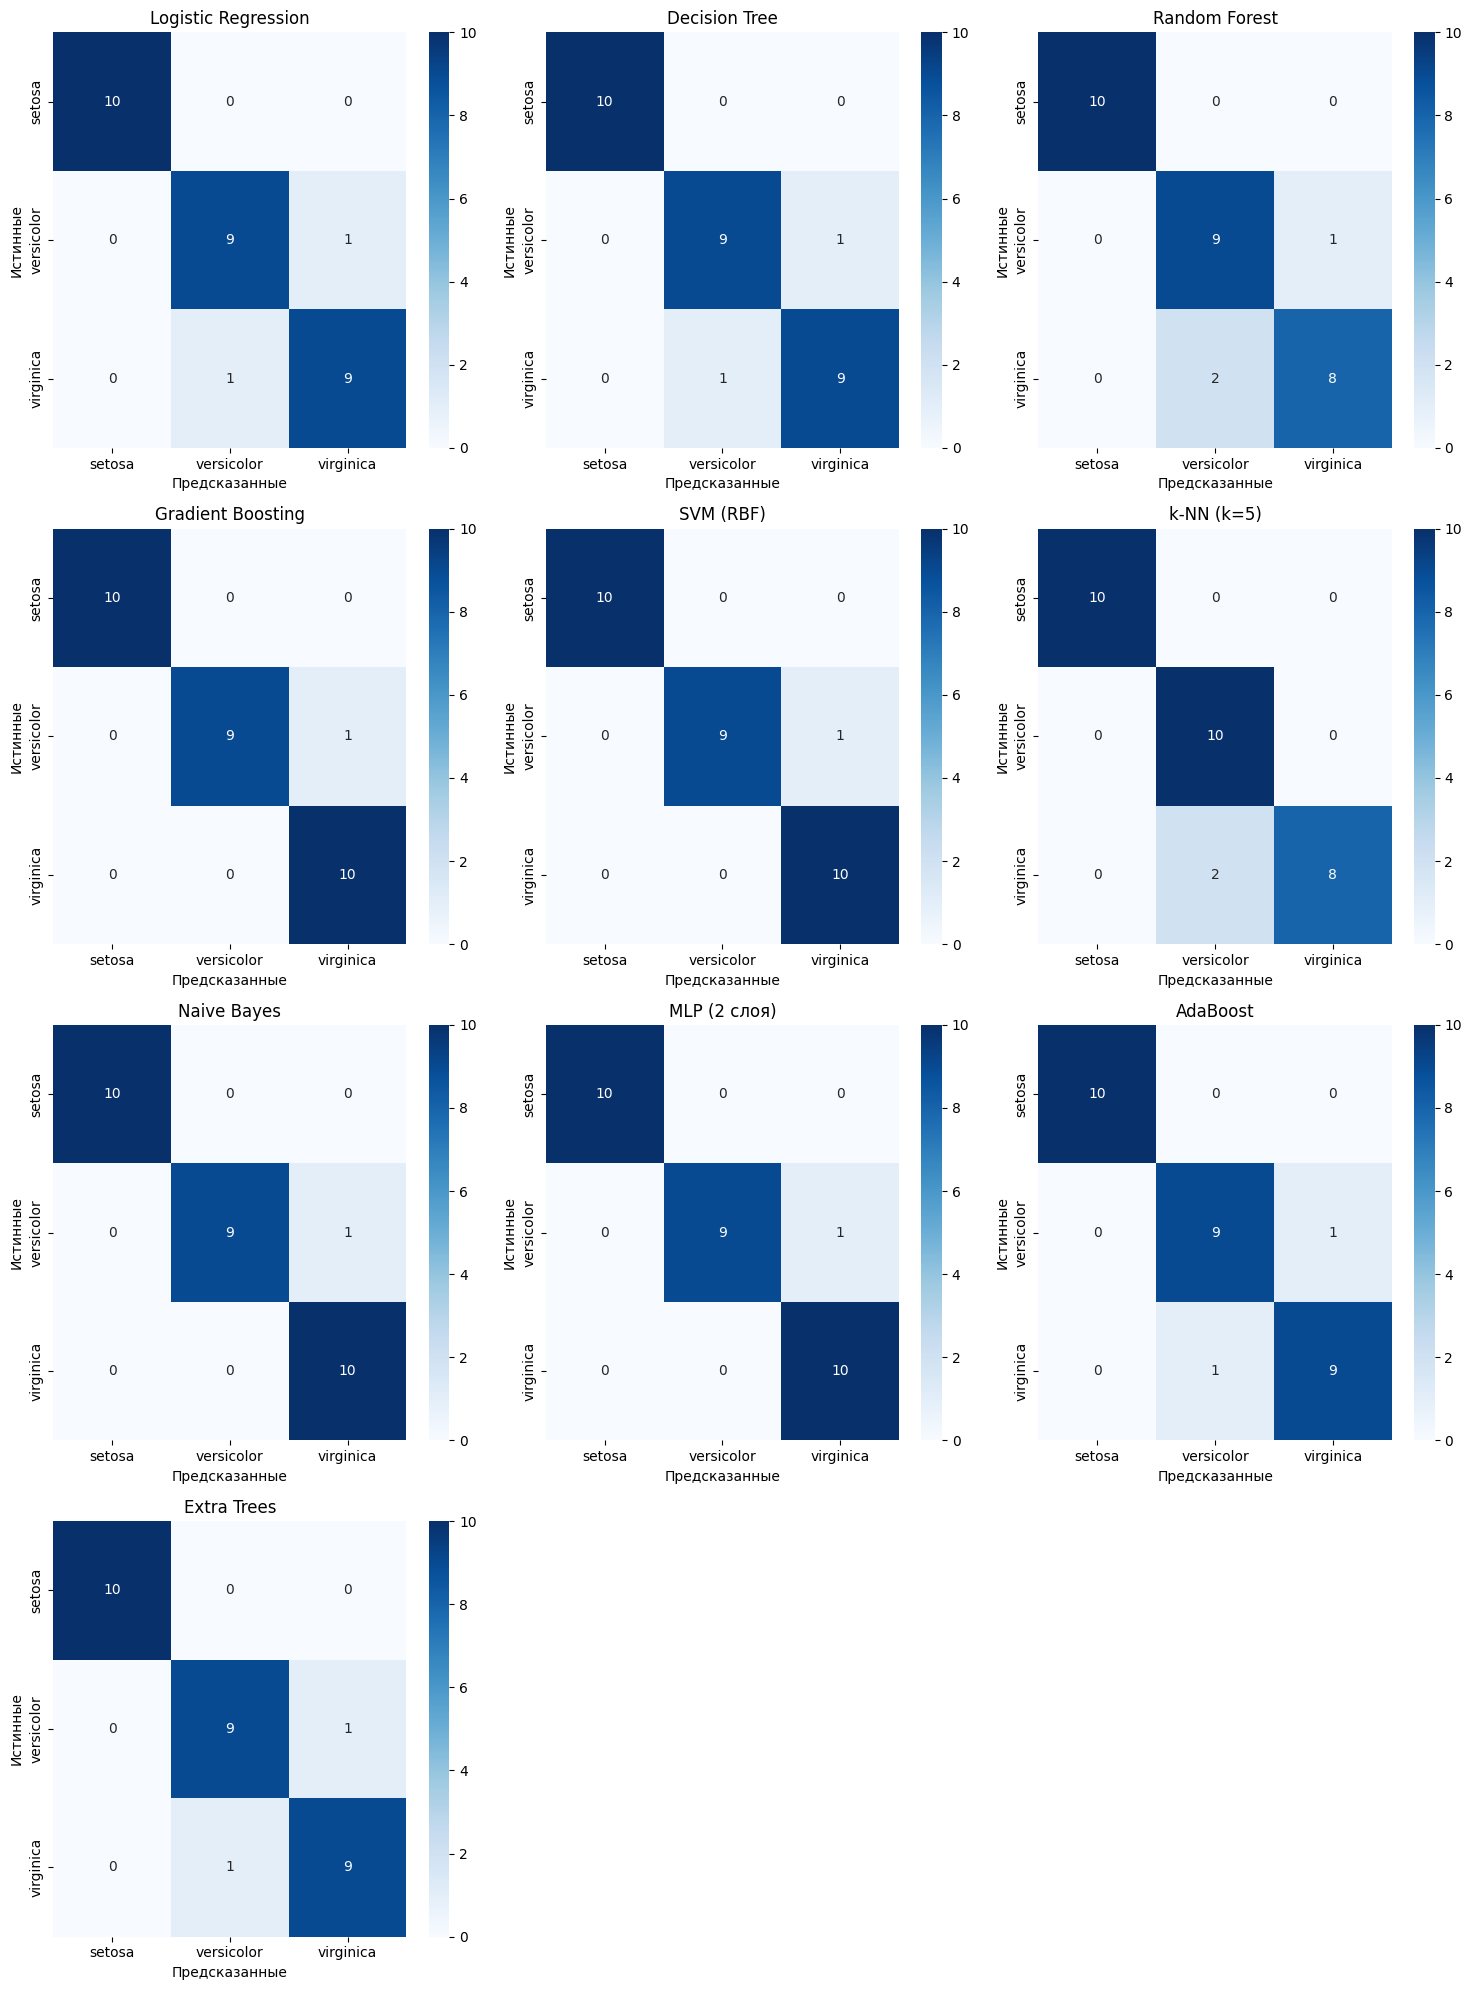

In [35]:


# 7. Матрицы ошибок в сетке 3x4 (10 моделей -> 4 строки по 3)
n_models = len(models)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(preds_test.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=target_names, yticklabels=target_names)
    axes[i].set_title(name)
    axes[i].set_xlabel('Предсказанные')
    axes[i].set_ylabel('Истинные')

# Удаляем лишние подграфики
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [36]:
# 8. Детальный анализ лучшей модели (по F1-score)
best_model_name = results_df.iloc[0]["Model"]
best_y_pred = preds_test[best_model_name]
best_y_pred_train = preds_train[best_model_name]

print(f"\n=== Детальный анализ лучшей модели: {best_model_name} ===")
print("\nОтчёт о классификации на тесте:")
print(classification_report(y_test, best_y_pred, target_names=target_names))

metrics_table = pd.DataFrame({
    "Train": [
        accuracy_score(y_train, best_y_pred_train),
        precision_score(y_train, best_y_pred_train, average='macro', zero_division=0),
        recall_score(y_train, best_y_pred_train, average='macro', zero_division=0),
        f1_score(y_train, best_y_pred_train, average='macro', zero_division=0),
    ],
    "Test": [
        accuracy_score(y_test, best_y_pred),
        precision_score(y_test, best_y_pred, average='macro', zero_division=0),
        recall_score(y_test, best_y_pred, average='macro', zero_division=0),
        f1_score(y_test, best_y_pred, average='macro', zero_division=0),
    ]
}, index=["Accuracy", "Precision", "Recall", "F1"])

print("\nСравнение метрик на обучающей и тестовой выборках (макро):")
metrics_table


=== Детальный анализ лучшей модели: SVM (RBF) ===

Отчёт о классификации на тесте:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


Сравнение метрик на обучающей и тестовой выборках (макро):


,Train,Test
Accuracy,0.975000,0.966667
Precision,0.975193,0.969697
Recall,0.975000,0.966667
F1,0.974996,0.966583


## Вывод по заданию 2 (множественная классификация на Iris)

- **Лучшая модель** – SVM (RBF) с F1-score = 0.967, Accuracy = 0.967.
- Также отличные результаты показали Gradient Boosting, MLP (2 слоя), Naive Bayes (F1 ≈ 0.967).
- Random Forest неожиданно показал худший результат (F1 = 0.900) среди всех моделей, что может быть связано с настройками по умолчанию.

- **Анализ ошибок SVM (RBF):**  
  - Setosa – 100% (10/10)  
  - Versicolor – 90% (9/10), одна ошибка отнесена к virginica  
  - Virginica – 100% (10/10)  

- **Train vs Test:** метрики на обучении (0.975) незначительно выше, чем на тесте (0.967), переобучение минимально.

- **Вывод:** На сбалансированном и хорошо разделимом датасете Iris большинство моделей показывают высокое качество (F1 ≈ 0.93–0.97). SVM (RBF) дала наилучший баланс точности и полноты по всем трём классам.

3. Повторите анализ для датасета, предназначенного для решения задачи регрессии. Используйте все метрики качества регрессии, изученные на лекции. Постройте 5–10 разных моделей регрессии.

In [40]:
from sklearn.datasets import fetch_california_housing

# 1. Загрузка данных (регрессия)
housing = fetch_california_housing()
X = housing.data
y = housing.target
feature_names = housing.feature_names

print("Датасет California Housing")
print(f"Размер X: {X.shape}, целевая переменная: MedHouseVal (сотни тысяч долларов)")
print(f"Признаки: {feature_names}")

data.head()

Датасет California Housing
Размер X: (20640, 8), целевая переменная: MedHouseVal (сотни тысяч долларов)
Признаки: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [41]:
# 2. Разделение на train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [42]:
# 3. Масштабирование (для моделей, чувствительных к масштабу: линейные, SVM, KNN, MLP)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

# 4. Список моделей регрессии
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=1)': Ridge(alpha=1),
    'Lasso (alpha=0.1)': Lasso(alpha=0.1),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'KNN (k=5)': KNeighborsRegressor(n_neighbors=5),
    'SVR (RBF)': SVR(kernel='rbf', C=1, gamma='scale'),
    'MLP (2 слоя)': MLPRegressor(hidden_layer_sizes=(50, 25), max_iter=1000, random_state=42),
    'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=42)
}

In [53]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 5. Обучение и сбор метрик на тесте
results = []
preds_test = {}

for name, model in models.items():
    # Для моделей, чувствительных к масштабу, используем scaled
    if name in ['Linear Regression', 'Ridge (alpha=1)', 'Lasso (alpha=0.1)', 'KNN (k=5)', 'SVR (RBF)', 'MLP (2 слоя)']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    preds_test[name] = y_pred
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append([name, mse, rmse, mae, r2])

In [54]:
# 6. Сводная таблица метрик (сортировка по R²)
results_df = pd.DataFrame(results, columns=["Model", "MSE", "RMSE", "MAE", "R²"])
results_df = results_df.sort_values(by="R²", ascending=False)
print("\n=== Сводка метрик регрессии на тестовой выборке ===")
results_df


=== Сводка метрик регрессии на тестовой выборке ===


,Model,MSE,RMSE,MAE,R²
4,Random Forest,0.255368,0.505340,0.327543,0.805123
8,MLP (2 слоя),0.271516,0.521072,0.354924,0.792800
5,Gradient Boosting,0.293997,0.542215,0.371643,0.775645
7,SVR (RBF),0.357003,0.597497,0.398598,0.727564
6,KNN (k=5),0.432422,0.657588,0.446154,0.670010
3,Decision Tree,0.495235,0.703729,0.454679,0.622076
1,Ridge (alpha=1),0.555855,0.745557,0.533193,0.575816
0,Linear Regression,0.555892,0.745581,0.533200,0.575788
9,AdaBoost,0.614478,0.783887,0.649788,0.531079
2,Lasso (alpha=0.1),0.679629,0.824396,0.622201,0.481361


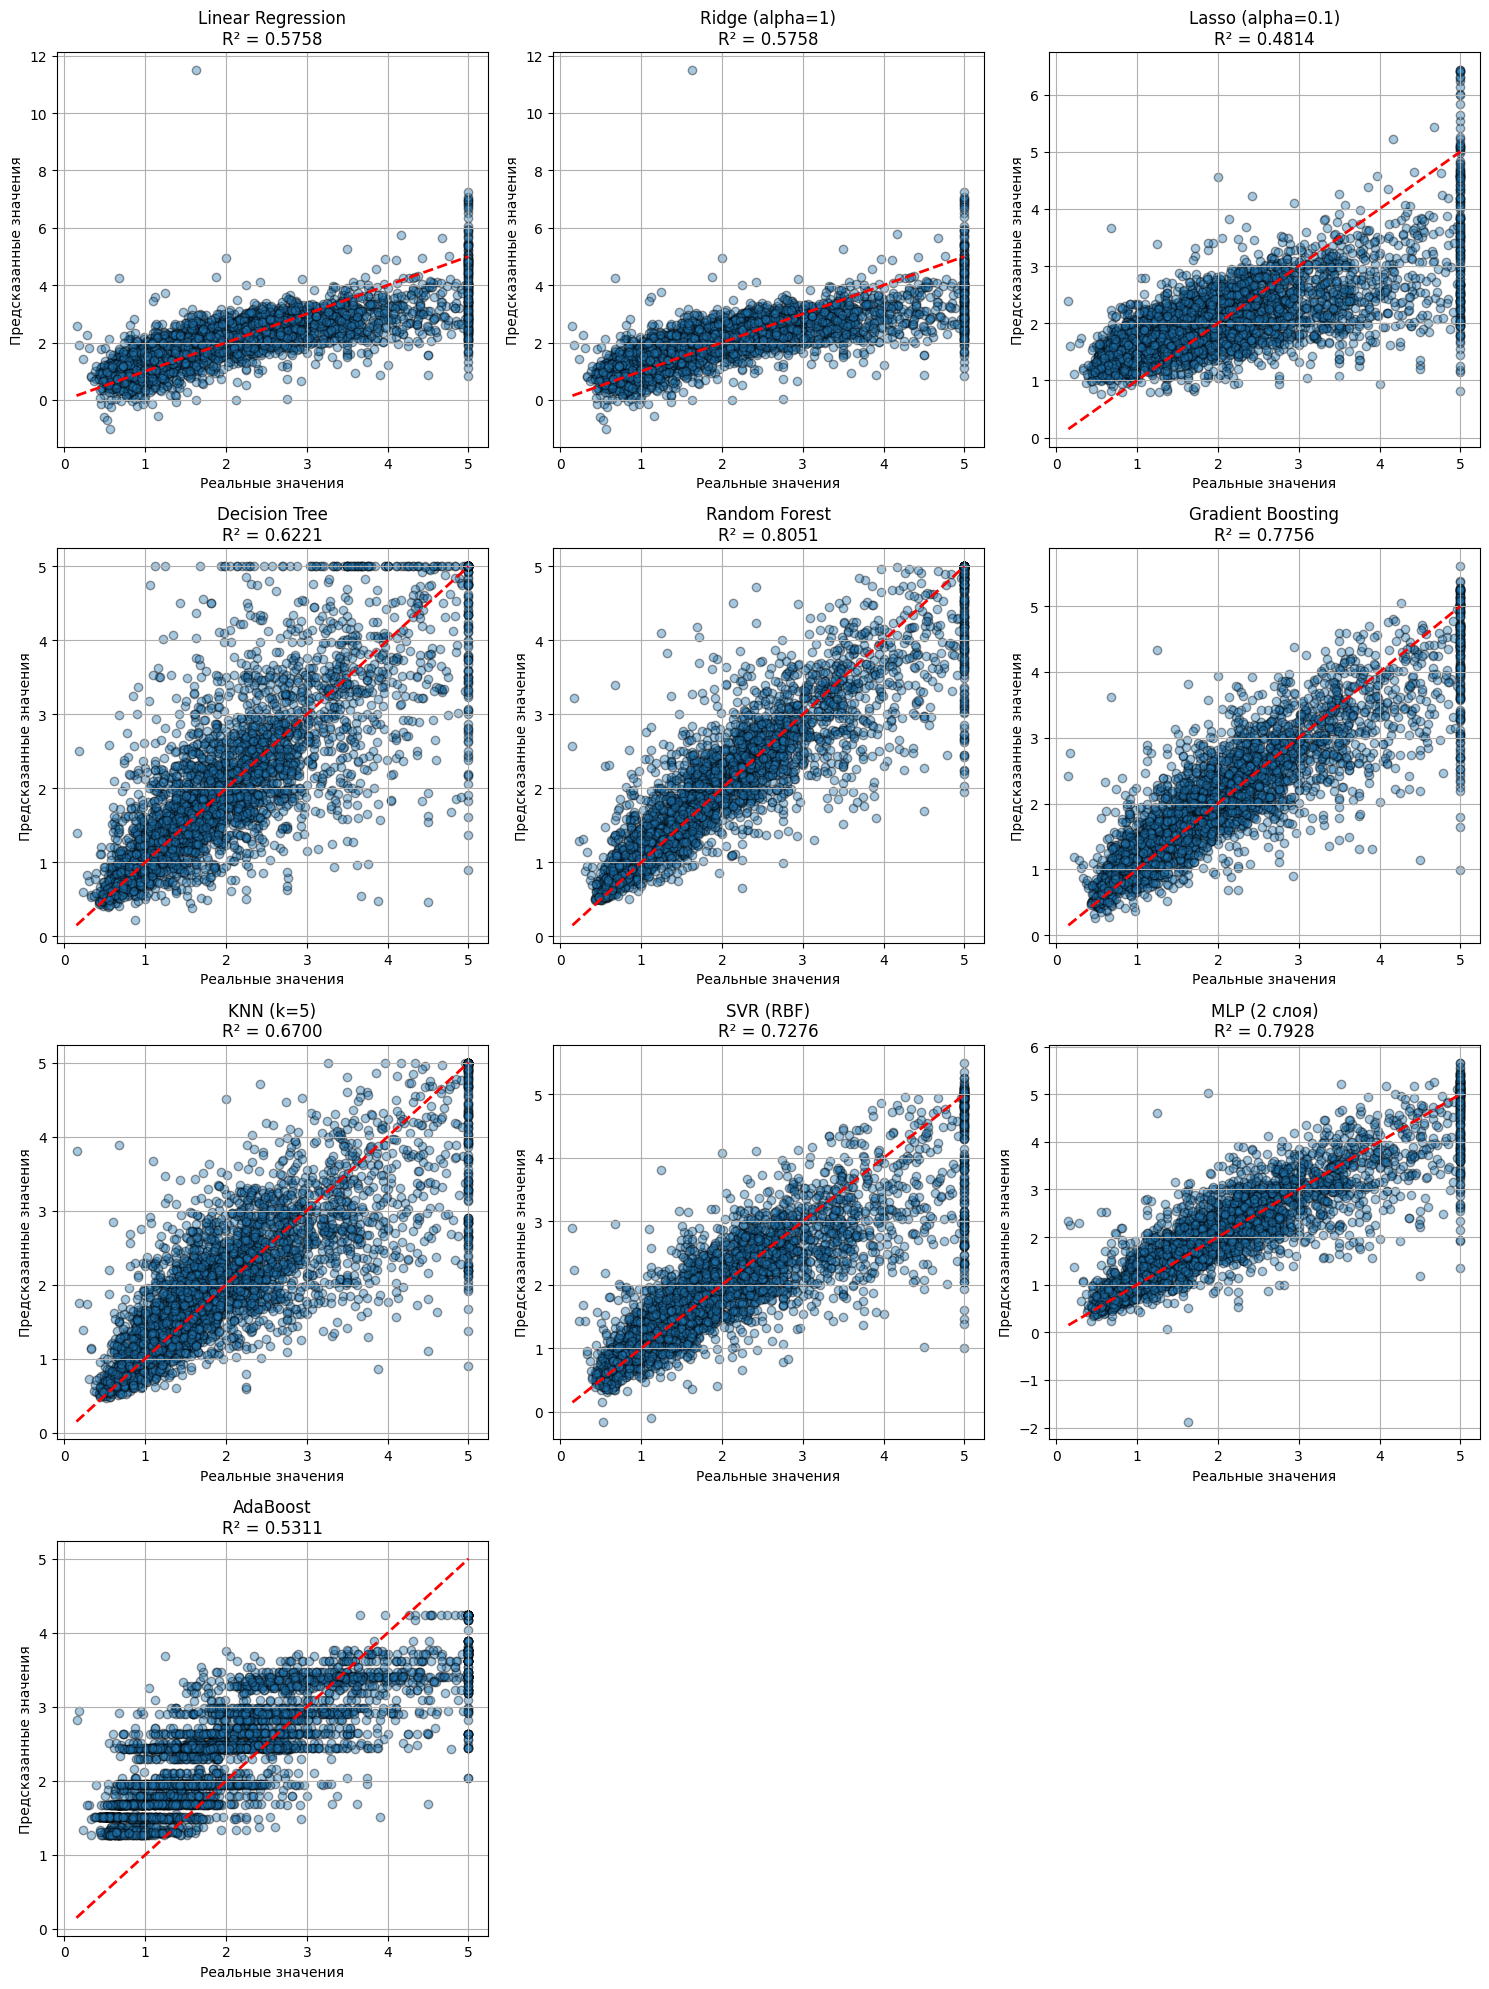

In [58]:
# 7. Визуализация предсказаний для всех моделей (в сетке 3 столбца)
n_models = len(preds_test)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(preds_test.items()):
    ax = axes[i]
    ax.scatter(y_test, y_pred, alpha=0.4, edgecolors='k')
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_xlabel("Реальные значения")
    ax.set_ylabel("Предсказанные значения")
    ax.set_title(f"{name}\nR² = {r2_score(y_test, y_pred):.4f}")
    ax.grid(True)

# Удаляем лишние подграфики
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [56]:
# 8. Детальный анализ лучшей модели (сравнение Train vs Test метрик)
best_model = models[best_model_name]
if best_model_name in ['Linear Regression', 'Ridge (alpha=1)', 'Lasso (alpha=0.1)', 'KNN (k=5)', 'SVR (RBF)', 'MLP (2 слоя)']:
    best_model.fit(X_train_scaled, y_train)
    y_pred_train = best_model.predict(X_train_scaled)
    y_pred_test = best_model.predict(X_test_scaled)
else:
    best_model.fit(X_train, y_train)
    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)

print(f"\n=== Детальный анализ лучшей модели: {best_model_name} ===")
print(f"MSE на обучении: {mean_squared_error(y_train, y_pred_train):.4f}")
print(f"MSE на тесте: {mean_squared_error(y_test, y_pred_test):.4f}")
print(f"R² на обучении: {r2_score(y_train, y_pred_train):.4f}")
print(f"R² на тесте: {r2_score(y_test, y_pred_test):.4f}")



=== Детальный анализ лучшей модели: Random Forest ===
MSE на обучении: 0.0353
MSE на тесте: 0.2554
R² на обучении: 0.9736
R² на тесте: 0.8051


## Вывод по заданию 3 (регрессия на California Housing)

- **Лучшая модель** – Random Forest (R² = 0.805, MSE = 0.255).  
- Второй результат у MLP (2 слоя) (R² = 0.793), третий – у Gradient Boosting (R² = 0.776).  
- SVR с RBF ядром дал R² = 0.728, KNN – 0.670.  
- Линейные модели (Ridge, LinearRegression) показали R² ≈ 0.576, Lasso – 0.481 (хуже всех).  
- Decision Tree и AdaBoost также уступают ансамблям (R² ≈ 0.62 и 0.53).  

- **Переобучение у Random Forest**: R² на обучении = 0.974, на тесте = 0.805 – значительный разрыв, но качество на тесте остаётся высоким.  
- **Вывод**: Для регрессии на California Housing ансамблевые методы (Random Forest, Gradient Boosting) и MLP работают лучше всего. Линейные модели недостаточно гибки для такой нелинейной зависимости. Рекомендуется использовать Random Forest с настройкой гиперпараметров для снижения переобучения.